<a href="https://colab.research.google.com/github/venkat269/EEG-signal/blob/main/Doberman_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Import all required libraries
# OpenCV is used for image processing.
# NumPy is used for numerical operations.
# Matplotlib is used to display images.
# OS and shutil are used for folders and ZIP files.

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

from google.colab import files

In [ ]:
# CELL 2: Upload the Doberman images
# Select all 15 images from your computer.

uploaded = files.upload()

print("Number of images uploaded:", len(uploaded))

Saving doberman_1.jpg to doberman_1.jpg
Saving doberman_2.jpg to doberman_2.jpg
Saving doberman_3.jpg to doberman_3.jpg
Saving doberman_4.jpg to doberman_4.jpg
Saving doberman_5.jpg to doberman_5.jpg
Saving doberman_6.jpg to doberman_6.jpg
Saving doberman_7.jpg to doberman_7.jpg
Saving doberman_8.jpg to doberman_8.jpg
Saving doberman_9.jpg to doberman_9.jpg
Saving doberman_10.jpg to doberman_10.jpg
Saving doberman_11.jpg to doberman_11.jpg
Saving doberman_12.jpg to doberman_12.jpg
Saving doberman_13.jpg to doberman_13.jpg
Saving doberman_14.jpg to doberman_14.jpg
Saving doberman_15.jpg to doberman_15.jpg
Number of images uploaded: 15


In [ ]:
# CELL 3: Display the names of all uploaded images
# This confirms that the images were uploaded successfully.

print("Uploaded Doberman images:")

for filename in uploaded.keys():
    print(filename)

Uploaded Doberman images:
doberman_1.jpg
doberman_2.jpg
doberman_3.jpg
doberman_4.jpg
doberman_5.jpg
doberman_6.jpg
doberman_7.jpg
doberman_8.jpg
doberman_9.jpg
doberman_10.jpg
doberman_11.jpg
doberman_12.jpg
doberman_13.jpg
doberman_14.jpg
doberman_15.jpg


In [ ]:
# CELL 4: Create a folder to store the preprocessed images
# The original images will remain unchanged.

output_folder = "Preprocessed_Doberman"

os.makedirs(output_folder, exist_ok=True)

print("Output folder created:", output_folder)

Output folder created: Preprocessed_Doberman


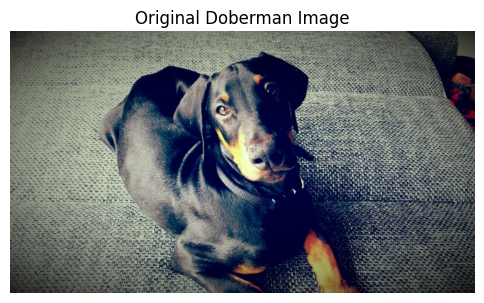

Original image size: (450, 800, 3)


In [ ]:
# CELL 5: Read and display the first Doberman image
# This allows us to verify that OpenCV can read the image correctly.

first_filename = list(uploaded.keys())[0]

image = cv2.imread(first_filename)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(image_rgb)
plt.title("Original Doberman Image")
plt.axis("off")
plt.show()

print("Original image size:", image.shape)

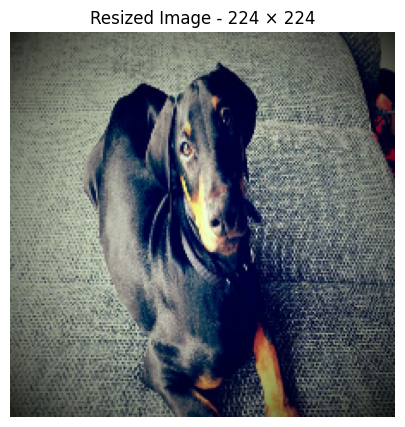

New image size: (224, 224, 3)


In [ ]:
# CELL 6: Resize the image
# All images are converted to a fixed size of 224 × 224 pixels.
# This ensures that every image has the same dimensions.

resized = cv2.resize(image_rgb, (224, 224))

plt.figure(figsize=(6, 5))
plt.imshow(resized)
plt.title("Resized Image - 224 × 224")
plt.axis("off")
plt.show()

print("New image size:", resized.shape)

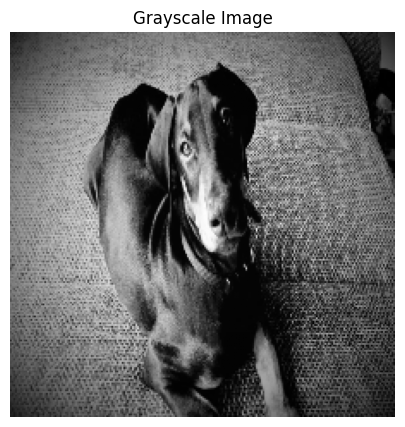

Grayscale image size: (224, 224)


In [ ]:
# CELL 7: Convert the resized image to grayscale
# Grayscale removes color information and represents the image
# using intensity values.

gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

print("Grayscale image size:", gray.shape)

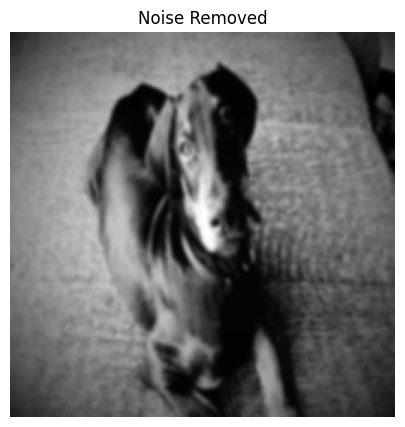

In [ ]:
# CELL 8: Remove image noise
# Gaussian Blur is used to smooth the image and reduce small
# unwanted variations or noise.

denoised = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(6, 5))
plt.imshow(denoised, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.show()

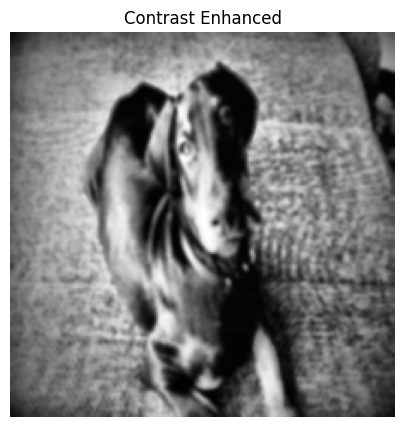

In [ ]:
# CELL 9: Enhance image contrast
# CLAHE improves local contrast and helps make details
# more visible, especially when lighting is uneven.

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced = clahe.apply(denoised)

plt.figure(figsize=(6, 5))
plt.imshow(enhanced, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")
plt.show()

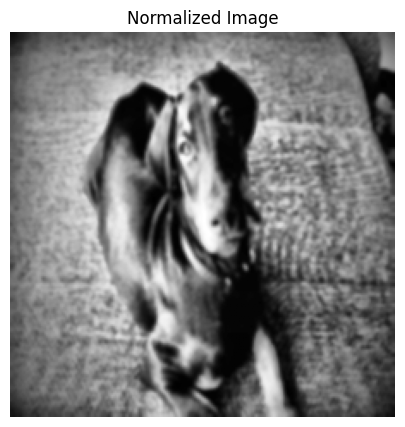

Minimum value: 0.00784313725490196
Maximum value: 1.0


In [ ]:
# CELL 10: Normalize pixel values
# Original image pixels normally range from 0 to 255.
# Dividing by 255 converts them to a range of 0 to 1.

normalized = enhanced / 255.0

plt.figure(figsize=(6, 5))
plt.imshow(normalized, cmap="gray")
plt.title("Normalized Image")
plt.axis("off")
plt.show()

print("Minimum value:", normalized.min())
print("Maximum value:", normalized.max())

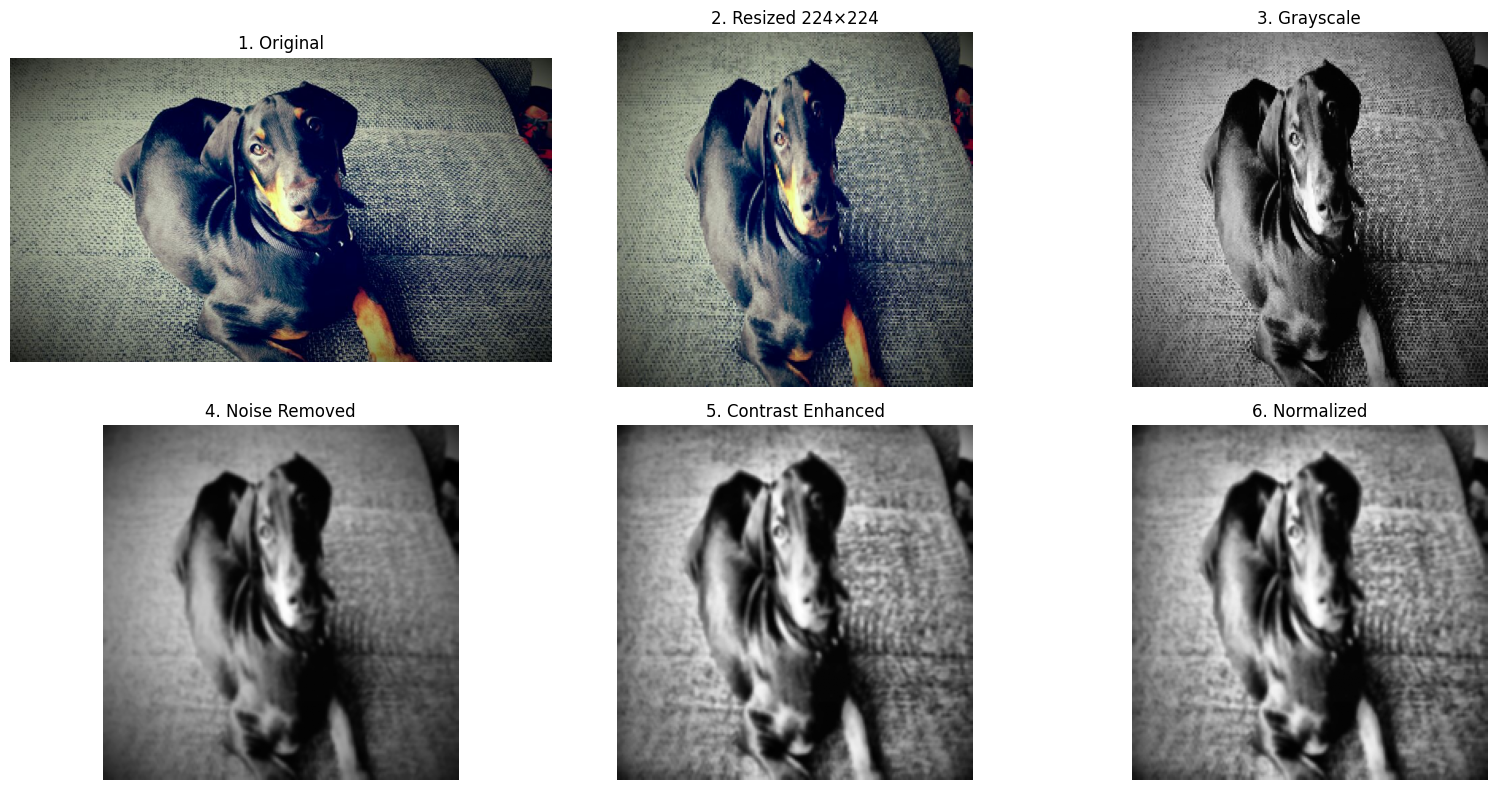

In [ ]:
# CELL 11: Display all preprocessing stages together
# This gives a visual explanation of how the original image
# changes through each preprocessing step.

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("1. Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized)
plt.title("2. Resized 224×224")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("3. Grayscale")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(denoised, cmap="gray")
plt.title("4. Noise Removed")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(enhanced, cmap="gray")
plt.title("5. Contrast Enhanced")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(normalized, cmap="gray")
plt.title("6. Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# CELL 12: Apply all preprocessing steps to all 15 Doberman images
# Each image is resized, converted to grayscale, denoised,
# contrast enhanced and normalized.

processed_images = []

for filename in uploaded.keys():

    image = cv2.imread(filename)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (224, 224))

    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

    denoised = cv2.GaussianBlur(gray, (5, 5), 0)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(denoised)

    normalized = enhanced / 255.0

    processed_images.append({
        "filename": filename,
        "original": image_rgb,
        "resized": resized,
        "grayscale": gray,
        "denoised": denoised,
        "enhanced": enhanced,
        "normalized": normalized
    })

print("Preprocessing completed successfully!")
print("Total images processed:", len(processed_images))

Preprocessing completed successfully!
Total images processed: 15


In [ ]:
# CELL 13: Save the preprocessed images
# The normalized images are converted back to 0–255 before saving,
# because standard image files store pixel values in this range.

for data in processed_images:

    save_image = (data["normalized"] * 255).astype(np.uint8)

    output_path = os.path.join(
        output_folder,
        data["filename"]
    )

    cv2.imwrite(output_path, save_image)

print("All preprocessed images saved successfully!")

All preprocessed images saved successfully!


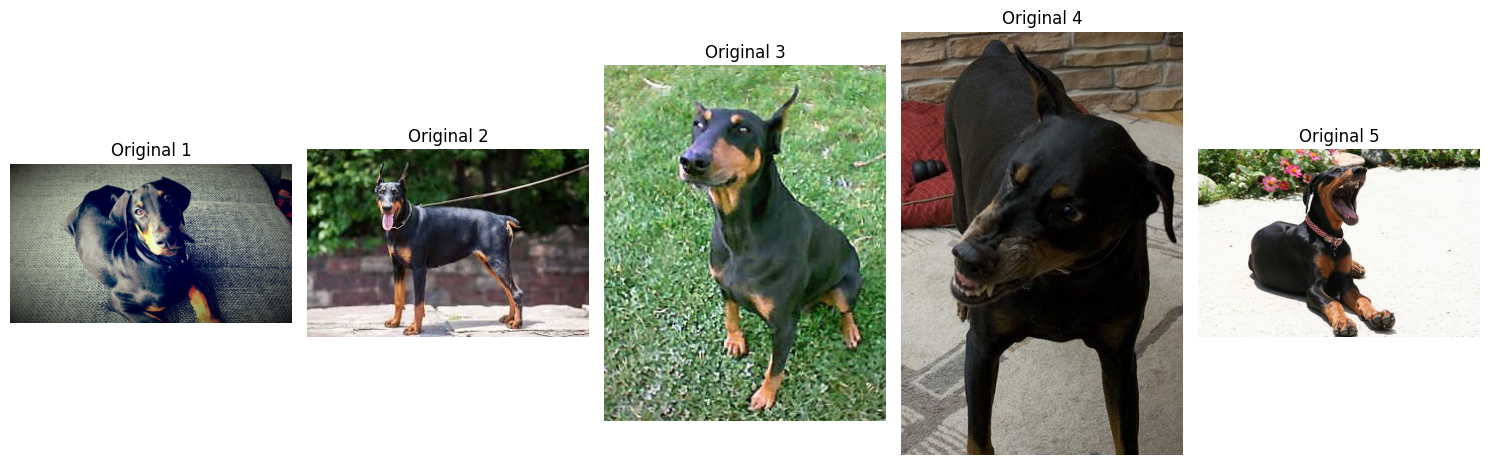

In [ ]:
# CELL 14: Display five original Doberman images
# This allows us to inspect the original dataset.

plt.figure(figsize=(15, 6))

for i in range(min(5, len(processed_images))):

    plt.subplot(1, 5, i + 1)
    plt.imshow(processed_images[i]["original"])
    plt.title(f"Original {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

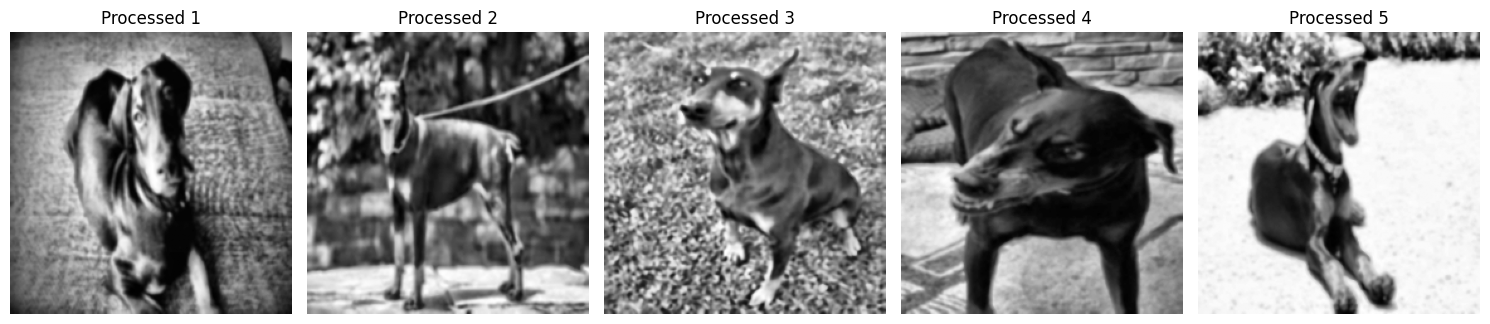

In [ ]:
# CELL 15: Display five preprocessed images
# These are the images after the complete preprocessing pipeline.

plt.figure(figsize=(15, 6))

for i in range(min(5, len(processed_images))):

    plt.subplot(1, 5, i + 1)
    plt.imshow(processed_images[i]["normalized"], cmap="gray")
    plt.title(f"Processed {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

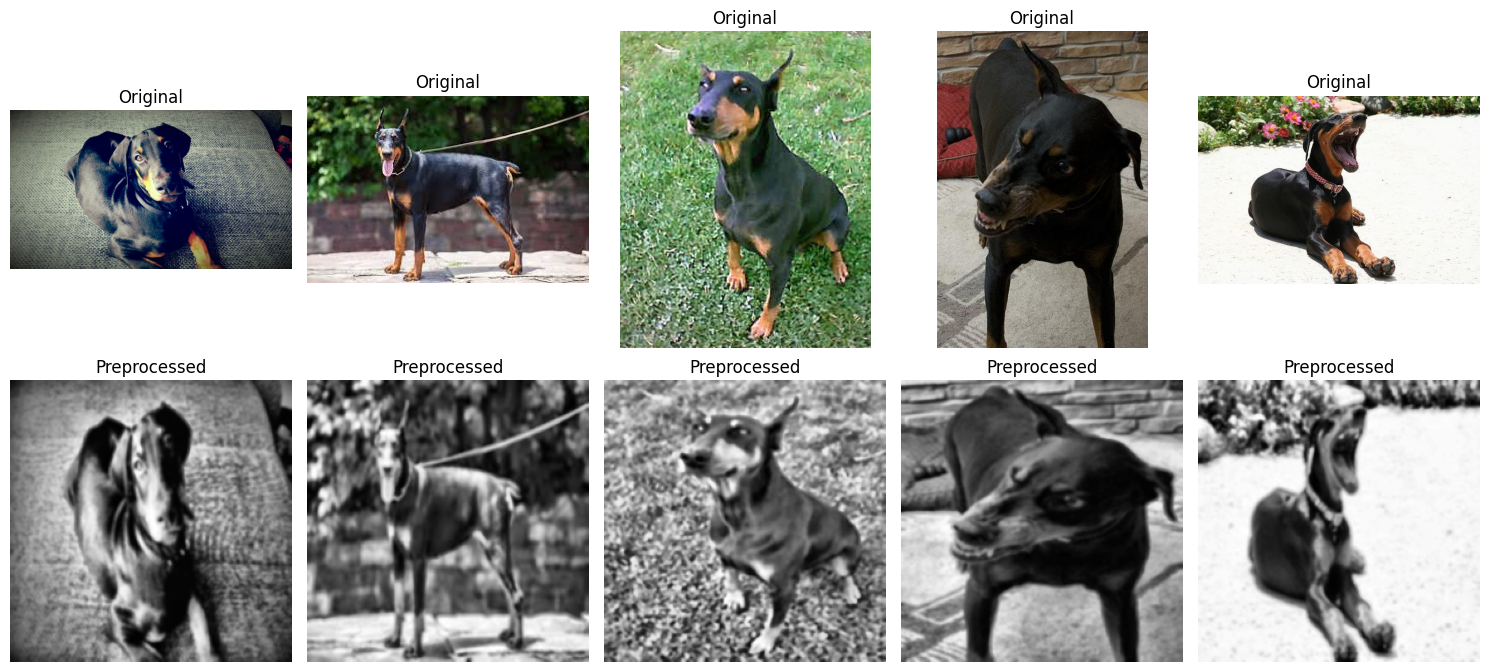

In [ ]:
# CELL 16: Compare original and preprocessed images
# The top row shows the original images.
# The bottom row shows the corresponding preprocessed images.

plt.figure(figsize=(15, 7))

for i in range(min(5, len(processed_images))):

    plt.subplot(2, 5, i + 1)
    plt.imshow(processed_images[i]["original"])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(processed_images[i]["normalized"], cmap="gray")
    plt.title("Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# CELL 17: Verify that the images have been resized correctly

print("Original image shape:")
print(processed_images[0]["original"].shape)

print("\nResized image shape:")
print(processed_images[0]["resized"].shape)

print("\nGrayscale image shape:")
print(processed_images[0]["grayscale"].shape)

Original image shape:
(450, 800, 3)

Resized image shape:
(224, 224, 3)

Grayscale image shape:
(224, 224)


In [ ]:
# CELL 18: Verify that normalization was performed
# Pixel values should be within the range 0 to 1.

sample = processed_images[0]["normalized"]

print("Minimum normalized value:", sample.min())
print("Maximum normalized value:", sample.max())

Minimum normalized value: 0.00784313725490196
Maximum normalized value: 1.0


In [ ]:
# CELL 19: Confirm that all 15 images were processed

print("Number of original images:", len(uploaded))
print("Number of processed images:", len(processed_images))

Number of original images: 15
Number of processed images: 15


In [ ]:
# CELL 20: Compress the preprocessed dataset into a ZIP file
# This makes it easy to download and submit the processed dataset.

shutil.make_archive(
    "Preprocessed_Doberman",
    "zip",
    output_folder
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
# CELL 21: Download the final preprocessed dataset

files.download("Preprocessed_Doberman.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL 22: Display project information

print("=" * 50)
print("DOBERMAN IMAGE PREPROCESSING PROJECT")
print("=" * 50)

print("Dataset Class      : Doberman")
print("Number of Images   :", len(processed_images))
print("Resize Size        : 224 × 224")
print("Noise Removal      : Gaussian Blur")
print("Contrast Enhancement: CLAHE")
print("Normalization      : 0–255 → 0–1")
print("Output Folder      :", output_folder)

print("=" * 50)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 50)

DOBERMAN IMAGE PREPROCESSING PROJECT
Dataset Class      : Doberman
Number of Images   : 15
Resize Size        : 224 × 224
Noise Removal      : Gaussian Blur
Contrast Enhancement: CLAHE
Normalization      : 0–255 → 0–1
Output Folder      : Preprocessed_Doberman
PREPROCESSING COMPLETED SUCCESSFULLY
